In [1]:
# %pip install numpy
# %pip install matplotlib
# %pip install imageio

In [2]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [19]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 2137
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 1000 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 20 # used for episodic evaluation


In [47]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
V = np.full(num_states, 2137.0) # initialization for V(s) (can be anything)
V = np.array([0 if env.is_terminal_state(s) else V[s] for s in range(num_states)]) # terminal state has to have 0

# put your VI implementation here
# hint: environment has env.get_transition_distribution, env.is_terminal_state and env.reward functions to aid you
# try looking at these functions' docs for inspiration
for i in range(max_number_iterations):
    for s in range(num_states):
        values_for_a = [0] * len(ACTIONS)
        for a in ACTIONS:
            for p, s_next in env.get_transition_distribution(s, a):
                r = env.reward(s, a, s_next)
                values_for_a[a] += p * (r + gamma * V[s_next])
        if not env.is_terminal_state(s): # keep terminal at 0
            V[s] = np.max(values_for_a)

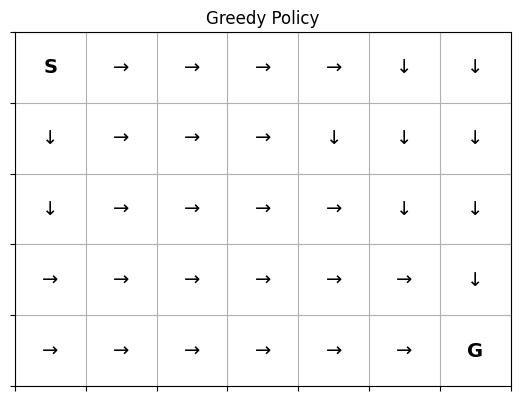

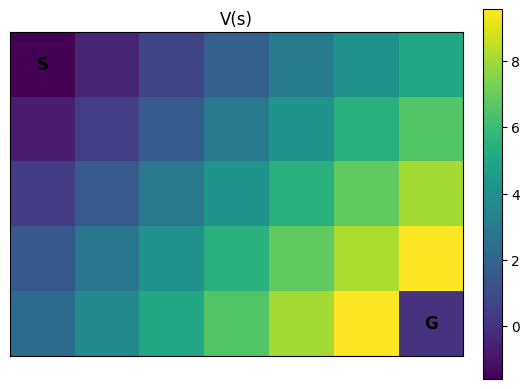

{'avg_return': -0.92, 'std_return': 1.8957, 'success_rate': 1.0, 'avg_steps': 11.92}


In [48]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)